# 전이성 유방암 90일 진단 예측 모델
**WiDS Datathon 2024 수상작 정성·정량적 개선 분석**
삼중전이유방암 환자가 선별 검사 후 90일 이내 전이성 암 진단을 받을지 예측하는 모델 개발
- 의료 형평성 해결

## 문제정의

전이성 유방암의 **90일 이내 진단 실패**는 사망 위험과 직결된다. WiDS Datathon 2024 수상작은 인구통계·환경 피처로 이를 예측했으나, 통계 검정 부재와 도메인 지식 부족이 있었다. 본 분석은 그 지점을 식별하고 논문 기반으로 개선한다.

목표: 수상작 기반으로 인구통계학 및 환경 피처를 이용해서 타겟과의 관계성 파악 후 이를 활용한 모델을 설계

### Load Datasets

In [17]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import seaborn as sns, matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

plt.rcParams['figure.dpi'] = 100
plt.rc('font', family='Malgun Gothic')

sns.set_style("whitegrid")

df  = pd.read_csv("data/training.csv")
tdf = pd.read_csv("data/test.csv")
ss  = pd.read_csv("data/sample_submission.csv")
target = "DiagPeriodL90D"
print(f"Train {df.shape} | Test {tdf.shape}")
df_raw = df.copy()

Train (12906, 83) | Test (5792, 82)


## EDA : 데이터 파악 및 수상작 변수 검토

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12906 entries, 0 to 12905
Data columns (total 83 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   patient_id                             12906 non-null  int64  
 1   patient_race                           6521 non-null   str    
 2   payer_type                             11103 non-null  str    
 3   patient_state                          12855 non-null  str    
 4   patient_zip3                           12906 non-null  int64  
 5   patient_age                            12906 non-null  int64  
 6   patient_gender                         12906 non-null  str    
 7   bmi                                    3941 non-null   float64
 8   breast_cancer_diagnosis_code           12906 non-null  str    
 9   breast_cancer_diagnosis_desc           12906 non-null  str    
 10  metastatic_cancer_diagnosis_code       12906 non-null  str    
 11  metastatic_fi

In [19]:
df.describe()

,patient_id,patient_zip3,patient_age,bmi,population,density,age_median,age_under_10,age_10_to_19,age_20s,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D
count,12906.000000,12906.000000,12906.000000,3941.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,...,12905.000000,12902.000000,12902.000000,12905.000000,12905.000000,12905.000000,12877.000000,12877.000000,12877.000000,12906.000000
mean,547381.196033,573.754300,59.183326,28.984539,20744.441237,1581.950419,40.502259,11.122784,12.945265,13.290376,...,13.335299,13.406950,4.474956,27.978387,8.575284,7.083376,39.822352,7.475221,16.098988,0.624516
std,260404.959974,275.447534,13.335216,5.696906,13886.903756,2966.305306,4.036963,1.512376,1.923974,3.354103,...,3.690949,5.222495,4.837085,5.083939,4.203482,3.109022,3.559492,1.516499,5.842501,0.484266
min,100063.000000,101.000000,18.000000,14.000000,635.545455,0.916667,20.600000,0.000000,6.314286,5.925000,...,4.600000,3.433333,0.000000,12.460784,2.440000,1.200000,30.939316,2.636008,2.760371,0.000000
25%,321517.000000,331.000000,50.000000,24.660000,9463.896552,171.857143,37.129825,10.160000,11.741176,11.013415,...,10.270492,9.663333,0.994444,24.933333,5.618750,4.929688,37.698880,6.651215,11.280694,0.000000
50%,543522.000000,554.000000,59.000000,28.190000,19154.190480,700.337500,40.639344,11.039216,12.923944,12.538095,...,12.884000,12.177778,2.747222,27.788235,7.465714,6.847059,39.108249,7.686577,15.589148,1.000000
75%,772671.750000,846.000000,67.000000,32.920000,30021.278690,1666.515385,42.934783,12.190000,14.019767,14.971053,...,15.555405,16.635556,5.976000,30.709375,10.617442,8.620000,41.136513,8.276922,20.801880,1.000000
max,999896.000000,999.000000,91.000000,85.000000,71374.131580,21172.000000,54.570000,17.675000,35.300000,62.100000,...,35.155556,38.347826,26.755000,48.020000,27.566102,25.200000,52.237210,11.169408,31.504775,1.000000


### 타겟 분포

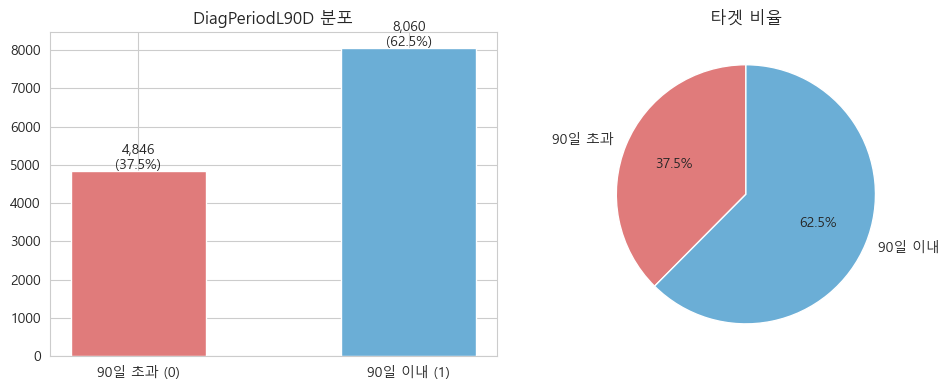

In [20]:
plt.rc('font', family='Malgun Gothic')
counts = df[target].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['90일 초과 (0)', '90일 이내 (1)'], counts.values, color=['#e07b7b','#6baed6'], width=0.5)
axes[0].set_title('DiagPeriodL90D 분포')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=['90일 초과','90일 이내'],
            autopct='%1.1f%%', colors=['#e07b7b','#6baed6'], startangle=90)
axes[1].set_title('타겟 비율')
plt.tight_layout(); plt.show()

In [21]:
zip3_counts = df['patient_zip3'].value_counts().max()
print(zip3_counts)

239


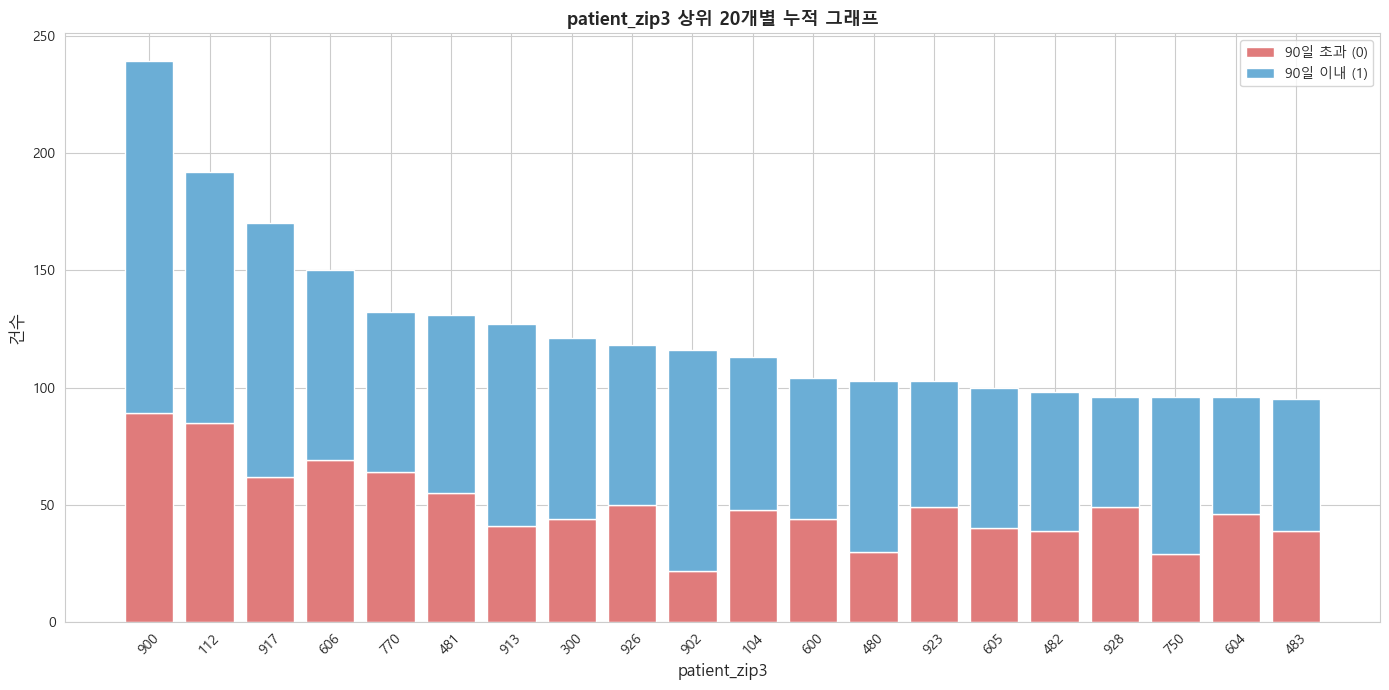

In [22]:
# patient_zip3별 target(0, 1) 분포 누적 막대그래프 + target=1(90일 이내) 분포 큰 zip3 상위 20개 추가

import matplotlib
matplotlib.rc("font", family="Malgun Gothic")  # 한글 폰트 설정
matplotlib.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

n = 20  # 상위 20개 시각화

## (1) 전체 상위 patient_zip3별 누적치 시각화
top_zip3 = df["patient_zip3"].value_counts().index[:n]
plot_df = df[df["patient_zip3"].isin(top_zip3)]
zip3_counts = (
    plot_df.groupby('patient_zip3')["DiagPeriodL90D"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(index=top_zip3, fill_value=0)
)
zip3_label = zip3_counts.index.astype(str)
plt.figure(figsize=(14, 7))
p1 = plt.bar(zip3_label, zip3_counts[0], label='90일 초과 (0)', color='#e07b7b')
p2 = plt.bar(zip3_label, zip3_counts[1], bottom=zip3_counts[0], label='90일 이내 (1)', color='#6baed6')
plt.title("patient_zip3 상위 20개별 누적 그래프", fontsize=13, fontweight="bold")
plt.xlabel("patient_zip3", fontsize=12)
plt.ylabel("건수", fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



### 결측치 현황

In [23]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12906 entries, 0 to 12905
Data columns (total 83 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   patient_id                             12906 non-null  int64  
 1   patient_race                           6521 non-null   str    
 2   payer_type                             11103 non-null  str    
 3   patient_state                          12855 non-null  str    
 4   patient_zip3                           12906 non-null  int64  
 5   patient_age                            12906 non-null  int64  
 6   patient_gender                         12906 non-null  str    
 7   bmi                                    3941 non-null   float64
 8   breast_cancer_diagnosis_code           12906 non-null  str    
 9   breast_cancer_diagnosis_desc           12906 non-null  str    
 10  metastatic_cancer_diagnosis_code       12906 non-null  str    
 11  metastatic_fi

                                       결측치 수  결측률(%)
metastatic_first_novel_treatment       12882    99.8
metastatic_first_novel_treatment_type  12882    99.8
bmi                                     8965    69.5
patient_race                            6385    49.5
payer_type                              1803    14.0
...                                      ...     ...
poverty                                    4     0.0
health_uninsured                           1     0.0
commute_time                               1     0.0
limited_english                            4     0.0
veteran                                    1     0.0

[75 rows x 2 columns]


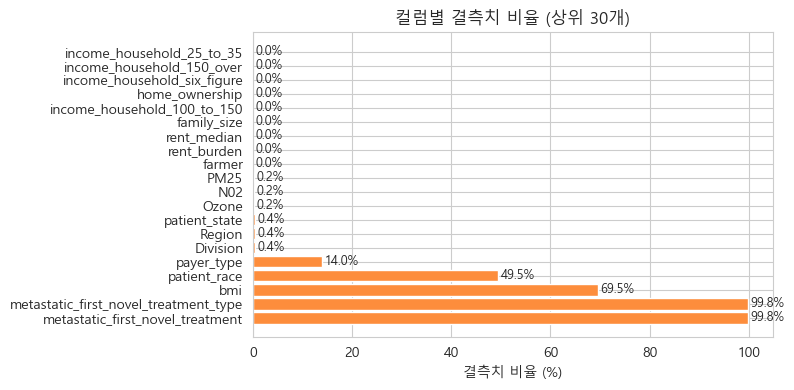

In [24]:

missing_df = (pd.DataFrame({
    "결측치 수": df.isnull().sum(),
    "결측률(%)": (df.isnull().mean() * 100).round(1)
})
.query("`결측치 수` > 0")
.sort_values("결측률(%)", ascending=False) 
)
print(missing_df)

miss = df.isnull().sum()
miss = (miss[miss > 0] / len(df) * 100).sort_values(ascending=False).round(1)
miss = miss.head(20)  # 상위 20개만

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(miss.index, miss.values, color='#fd8d3c')
for bar, pct in zip(bars, miss.values):
    ax.text(pct + 0.5, bar.get_y() + bar.get_height()/2, f'{pct}%', va='center', fontsize=9)
ax.set_xlabel('결측치 비율 (%)')
ax.set_title('컬럼별 결측치 비율 (상위 30개)')
plt.tight_layout(); plt.show()


### 주요 변수 분포 

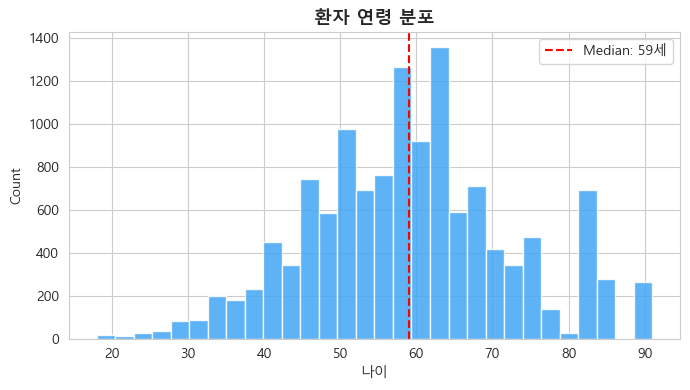

In [25]:

# 연령 분포
fig, axes = plt.subplots(1, 1, figsize=(7, 4))
axes.hist(df["patient_age"], bins=30, color="#42A5F5", edgecolor="white", alpha=0.85)
axes.axvline(df["patient_age"].median(), color="red", linestyle="--",
             label=f"Median: {df['patient_age'].median():.0f}세")
axes.set_title("환자 연령 분포", fontsize=13, fontweight="bold")
axes.set_xlabel("나이")
axes.set_ylabel("Count")
axes.legend()
plt.tight_layout()
plt.show()



### 수상작 주요 변수 분석

#### `patient_race`(의료 형평성 핵심 변수): 
- (기존) 49.5% 결측치를 갖는 중요독립변수를 그대로 사용
- (개선) 논문(Han, Y.et al, Do Breast Quadrants Explain Racial Disparities in Breast Cancer Outcomes?(2019))을 근거로 나이브 베이즈 분류를 활용해 환자의 인종(P(인종))예측하여 결측치 보완
: P(인종|유방암 종양 위치, 환자 거주지)=P(유방암 종양 위치|인종)xP(환자 거주지|인종)xP(인종)

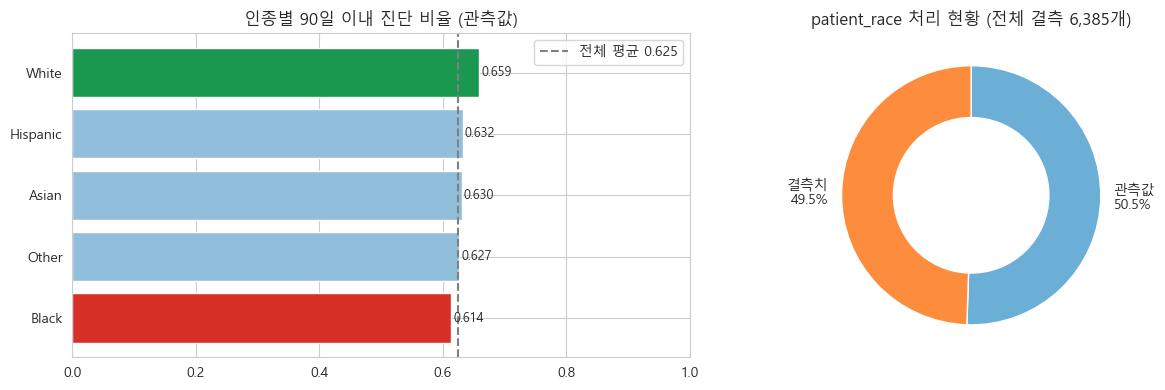

→ 인종별 진단 지연 차이 존재 — 의료 형평성 분석의 핵심 변수
→ 결측 49.5% : 결측치 보완 필요


In [26]:
# 인종별 90일 이내 진단 비율 (관측값)
rt = df.dropna(subset=['patient_race']).groupby('patient_race')[target].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['#d73027' if v == rt.min() else '#1a9850' if v == rt.max() else '#91bfdb' for v in rt.values]
axes[0].barh(rt.index, rt.values, color=colors)
axes[0].axvline(df[target].mean(), color='gray', linestyle='--', label=f'전체 평균 {df[target].mean():.3f}')
axes[0].set(xlim=(0, 1), title='인종별 90일 이내 진단 비율 (관측값)')
for i, v in enumerate(rt.values):
    axes[0].text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=9)
axes[0].legend()

# 결측치 처리 현황 — 도넛 그래프, 그래프 내에 % 표시
miss_n = df['patient_race'].isna().sum()
status_labels = ['관측값', '결측치']
counts = [len(df)-miss_n, miss_n]
colors = ['#6baed6', '#fd8d3c']
total = sum(counts)
percentages = [c/total*100 for c in counts]
labels_with_pct = [f"{lab}\n{pct:.1f}%" for lab, pct in zip(status_labels, percentages)]

# 도넛 파이 차트
wedges, texts = axes[1].pie(
    counts, labels=labels_with_pct, colors=colors, startangle=90, counterclock=False,
    wedgeprops=dict(width=0.4)
)
axes[1].set_title(f'patient_race 처리 현황 (전체 결측 {miss_n:,}개)')

plt.tight_layout()
plt.show()

print("→ 인종별 진단 지연 차이 존재 — 의료 형평성 분석의 핵심 변수")
print(f"→ 결측 {df['patient_race'].isnull().mean()*100:.1f}% : 결측치 보완 필요")

#### `전이암 진단코드(metastatic_cancer_diagnosis_code -> meta_code3 )` —  수상작 카이제곱 신뢰성 확보
- (기존)  
    전이암 ICD10 진단 코드, `metastatic_cancer_diagnosis_code`는 카이제곱 검정 시 유의수준이 0.05 미만이지만 기대빈도 < 5인 셀 비율이 25% 이상으로 χ² 검정결과를 신뢰할 수 없음(Selvin, s.Statistical Methods for Rates and Proportions.3rd ed., Wiley-Interscience,2024)

- (개선) 
    해당 코드를 기존 다섯자리에서 4자리로 자릿수(`meta_code4`)를 정규화(C7801,오른쪽 폐 전이암 -> C780 폐전이암)하여 해당 판정기준을 충족시킴

In [27]:

# 해당 변수와 타겟값의 유의수준(p-value) 판별(p-value를 지수형식으로 표시)
code_pvalues = []
for label, series in [
    ("5자리 (원본)", df['metastatic_cancer_diagnosis_code']),
    ("4자리 (개선)", df['metastatic_cancer_diagnosis_code'].str[:4]),
]:
    ct = pd.crosstab(series, df[target])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    code_pvalues.append((label, p))
    print(f"[{label}] p-value = {p:.2e} → {'유의함' if p < 0.05 else '유의하지 않음'}")
    


[5자리 (원본)] p-value = 2.11e-31 → 유의함
[4자리 (개선)] p-value = 2.78e-30 → 유의함


[5자리 (원본)] 기대값<5: 43.0% (37/86셀) / 신뢰성: 미충족
[4자리 (개선)] 기대값<5: 22.2% (12/54셀) / 신뢰성: 충족


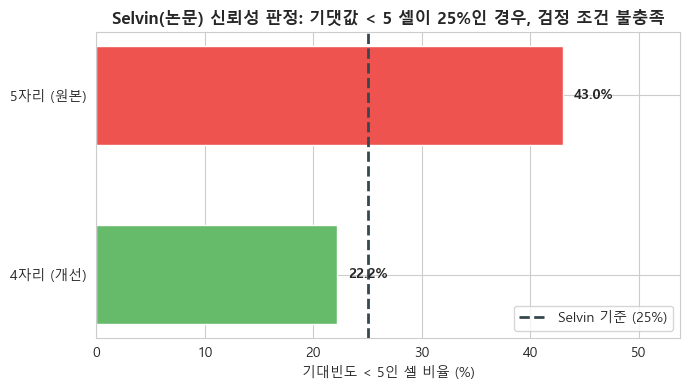

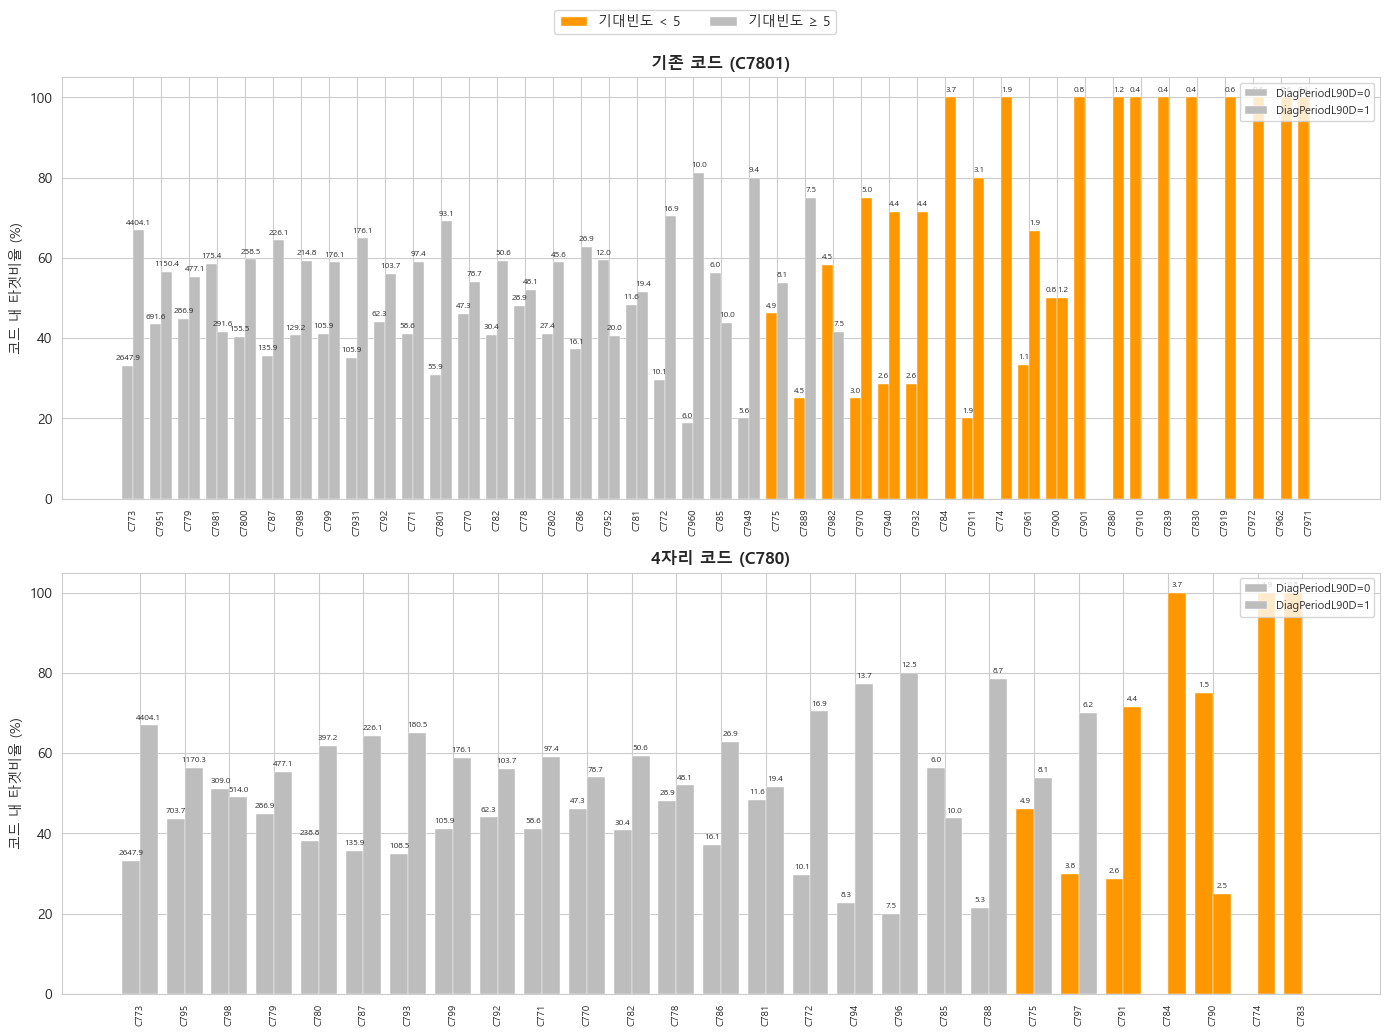

→ 4자리 변환 시 문제 셀 비율이 기존 43.0% (37/86셀)에서 22.2% (12/54셀)로 감소되어 Selvin 기준을 충족


In [28]:
import matplotlib
matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rc('axes', unicode_minus=False)

SELVIN_MAX_BAD_PCT = 25
MIN_EXP = 5

def plot_code_target(ax, series, title):
    ct = pd.crosstab(series.astype(str), df[target]).sort_index(axis=1)
    _, _, _, exp_arr = stats.chi2_contingency(ct)
    exp = pd.DataFrame(exp_arr, index=ct.index, columns=ct.columns)
    order = ct.sum(axis=1).sort_values(ascending=False).index
    ct, exp = ct.loc[order], exp.loc[order]
    pct = ct.div(ct.sum(axis=1), axis=0) * 100
    x, w = np.arange(len(ct)), 0.8 / len(ct.columns)
    for j, col in enumerate(ct.columns):
        off = (j - (len(ct.columns) - 1) / 2) * w
        bars = ax.bar(x + off, pct[col], width=w, label=f'{target}={int(col)}',
                      color=np.where(exp[col] < MIN_EXP, '#ff9800', '#bdbdbd'),
                      edgecolor='white', linewidth=0.3)
        for bar, e, p in zip(bars, exp[col], pct[col]):
            if p >= 4:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                        f'{e:.1f}', ha='center', va='bottom', fontsize=6)
    ax.set_xticks(x); ax.set_xticklabels(ct.index, rotation=90, fontsize=7)
    ax.set_ylim(0, 105); ax.set_ylabel('코드 내 타겟비율 (%)'); ax.set_title(title, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)

results = []
code_series = [
    ("5자리 (원본)", df['metastatic_cancer_diagnosis_code']),
    ("4자리 (개선)", df['metastatic_cancer_diagnosis_code'].str[:4]),
]

for label, series in code_series:
    ct = pd.crosstab(series, df[target])
    chi2, p, _, expected = stats.chi2_contingency(ct)
    bad_cells = int((expected < 5).sum())
    total_cells = expected.size
    bad_pct = bad_cells / total_cells * 100
    reliable = bad_pct < SELVIN_MAX_BAD_PCT
    results.append({'label': label, 'bad_pct': bad_pct, 'reliable': reliable,
                    'bad': bad_cells, 'total': total_cells})
    print(f"[{label}] 기대값<5: {bad_pct:.1f}% ({bad_cells}/{total_cells}셀) / "
          f"신뢰성: {'충족' if reliable else '미충족'}")

# (1) Selvin 신뢰성 판정
labels = [r['label'] for r in results]
bad_pcts = [r['bad_pct'] for r in results]
colors = ['#ef5350' if not r['reliable'] else '#66bb6a' for r in results]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(labels, bad_pcts, color=colors, edgecolor='white', height=0.55)
ax.axvline(SELVIN_MAX_BAD_PCT, color='#37474f', ls='--', lw=2, label=f'Selvin 기준 ({SELVIN_MAX_BAD_PCT}%)')
ax.set_xlim(0, max(bad_pcts) * 1.25)
ax.set_xlabel('기대빈도 < 5인 셀 비율 (%)')
ax.set_title('Selvin(논문) 신뢰성 판정: 기댓값 < 5 셀이 25%인 경우, 검정 조건 불충족', fontsize=12, fontweight='bold')
for bar, r in zip(bars, results):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{r['bad_pct']:.1f}%", va='center', fontsize=10, fontweight='bold')
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# (2) 코드별 target 비율(%) — 막대 위 숫자=기대빈도, 주황=기대빈도<5
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
plot_code_target(axes[0], code_series[0][1], '기존 코드 (C7801)')
plot_code_target(axes[1], code_series[1][1], '4자리 코드 (C780)')
from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor='#ff9800', label='기대빈도 < 5'),
                    Patch(facecolor='#bdbdbd', label='기대빈도 ≥ 5')],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, 1.0))
plt.tight_layout(); plt.show()

print("→ 4자리 변환 시 문제 셀 비율이 기존 43.0% (37/86셀)에서 22.2% (12/54셀)로 감소되어 Selvin 기준을 충족")

#### `유방암 진단 변수('breast_cancer_diagnosis_desc -> tumor_site`) - 논문 기반 피처의 타겟 연관성 향상
- (기존) 'breast_cancer_diagnosis_desc' 칼럼은 ICD10(ICD9) 코드에 대한 설명으로 가공되지 않은 텍스트로 고유값이 50개로 전처리가 요구됨
- (개선) Luo et at. Metastasis in breast cancer(2023)논문을 근거로 전이성에 대해 암의 부위에 걸친 종양을 7가지로 축소하고 위치별 가중치 부여(라벨 인코딩)

In [29]:
print(df['breast_cancer_diagnosis_desc'].value_counts())
print(len(df['breast_cancer_diagnosis_desc'].unique()))

breast_cancer_diagnosis_desc
Malignant neoplasm of breast (female), unspecified                  1982
Malignant neoplasm of unsp site of right female breast              1797
Malignant neoplasm of unspecified site of left female breast        1712
Malignant neoplasm of unsp site of unspecified female breast        1467
Malig neoplm of upper-outer quadrant of right female breast          978
Malig neoplasm of upper-outer quadrant of left female breast         877
Malignant neoplasm of ovrlp sites of right female breast             491
Malignant neoplasm of ovrlp sites of left female breast              419
Malignant neoplasm of upper-outer quadrant of female breast          389
Malignant neoplasm of other specified sites of female breast         307
Malig neoplasm of upper-inner quadrant of left female breast         293
Malig neoplm of upper-inner quadrant of right female breast          276
Malig neoplm of lower-outer quadrant of right female breast          213
Malignant neoplasm of 

In [30]:
#
df['desc_lower'] = df['breast_cancer_diagnosis_desc'].str.lower()
df['tumor_site_tmp'] = np.select(
    [
        df['desc_lower'].str.contains('upper-inner'),
        df['desc_lower'].str.contains('lower-inner'),
        df['desc_lower'].str.contains('upper-outer'),
        df['desc_lower'].str.contains('lower-outer'),
        df['desc_lower'].str.contains('axillary tail'),
        df['desc_lower'].str.contains('central portion') | df['desc_lower'].str.contains('nipple') | df['desc_lower'].str.contains('areola'),
        df['desc_lower'].str.contains('overlapping') | df['desc_lower'].str.contains('ovrlp'),
        df['desc_lower'].str.contains('unspecified') | df['desc_lower'].str.contains('unsp')
    ],
    [
        'Upper-inner',
        'Lower-inner',
        'Upper-outer',
        'Lower-outer',
        'Axillary tail',
        'Central',
        'Overlapping',
        'Unspecified'
    ],
    default='Unspecified'
)
print(df['tumor_site_tmp'].value_counts())

tumor_site_tmp
Unspecified      7319
Upper-outer      2302
Overlapping       972
Central           746
Upper-inner       681
Lower-outer       469
Lower-inner       348
Axillary tail      69
Name: count, dtype: int64


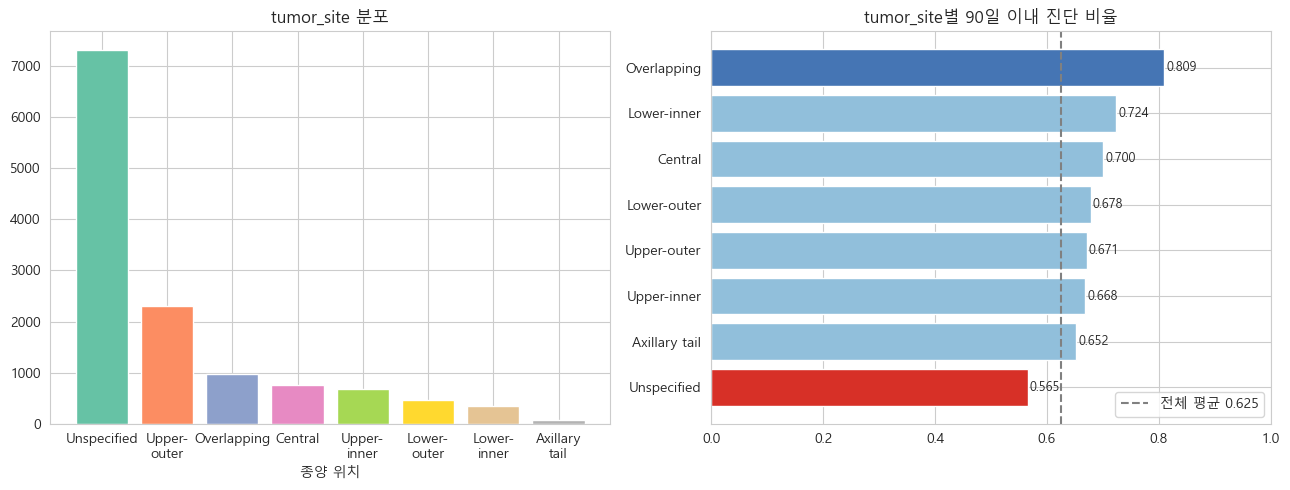

→ 종양 위치별 진단 지연 차이 존재 → tumor_site 피처 정당화


In [31]:
import matplotlib
import platform

sys_platform = platform.system()
if sys_platform == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
elif sys_platform == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
else:
    matplotlib.rc('font', family='NanumGothic')
matplotlib.rc('axes', unicode_minus=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc = df['tumor_site_tmp'].value_counts()

bar_labels = [x.replace(' ', '\n').replace('-', '-\n') if len(x) > 10 else x for x in sc.index]
bars = axes[0].bar(bar_labels, sc.values, color=sns.color_palette('Set2', len(sc)))
axes[0].set_title('tumor_site 분포')
axes[0].set_xlabel('종양 위치')

st = df.groupby('tumor_site_tmp')[target].mean().sort_values()
colors = ['#d73027' if v == st.min() else '#4575b4' if v == st.max() else '#91bfdb' for v in st.values]
axes[1].barh(st.index, st.values, color=colors)
axes[1].axvline(df[target].mean(), color='gray', ls='--', label=f'전체 평균 {df[target].mean():.3f}')
axes[1].set_xlim(0, 1)
axes[1].set_title('tumor_site별 90일 이내 진단 비율')
for i, (idx, v) in enumerate(st.items()):
    axes[1].text(v + 0.004, i, f'{v:.3f}', va='center', fontsize=9)
axes[1].legend()

plt.tight_layout()
plt.show()
print("→ 종양 위치별 진단 지연 차이 존재 → tumor_site 피처 정당화")

#### `breast_cancer_diagnosis_code` - ICD 구분 플래그 변수 생성
- (기존) 의료 체계 변화로 인해해 두개의 다른 ICD 코드 기재방식이 혼재되어 있음. 또한 ICD 버전마다 진단의 구체성에 의해 타겟값 분포가  상이함
- (개선) 코드이 차이를 반영하기 위한 새로운 플래그 변수(`ICD_version`) 생성

In [32]:
df['ICD_version'] = np.where(df['breast_cancer_diagnosis_code'].astype(str).str.startswith('C'), 'ICD-10', 'ICD-9')
print(df['ICD_version'].value_counts())

ICD_version
ICD-10    9915
ICD-9     2991
Name: count, dtype: int64


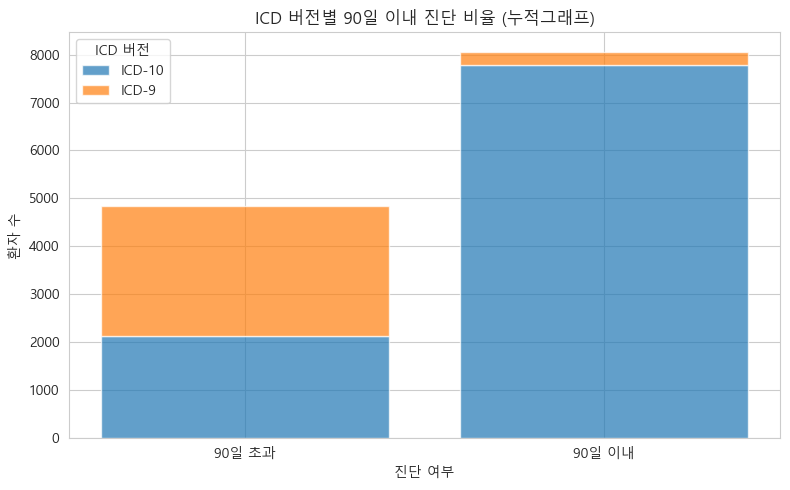

In [33]:
plt.figure(figsize=(8,5))
for version in df['ICD_version'].unique():
    values = df[df['ICD_version'] == version][target].value_counts().sort_index()
    plt.bar(values.index, values.values, label=version, alpha=0.7, bottom=plt.gca().patches and [item.get_height() for item in plt.gca().patches[:len(values)]] or None)
plt.xticks([0,1], ['90일 초과','90일 이내'])
plt.xlabel('진단 여부')
plt.ylabel('환자 수')
plt.title('ICD 버전별 90일 이내 진단 비율 (누적그래프)')
plt.legend(title='ICD 버전')
plt.tight_layout()
plt.show()

#### `환경 변수(NO2xPM25XOzone -> NO2xPM25XCoummute_time)` — Ozone 유의성 검증 및 복합 지수 설계
- (기존) Ozone과 유방암 사이 연관성 관찰X(논문(Hvidtfeldt et al., Cancer Epidemiology, Biomarkers & Prevention, (2023)) + 파생변수`NO2xPM25XOzone`t-test검정결과 p-value=0.8209)
- (개선) Ozone 대체 인자 'commute_time'을 통해 환경변수(`NO2xPM25XCommute_time`) 재설계 및 통계적유의성(p-value=0.0176)확보와와 논문(Commuting,Air Pollutinon, and Mortality in the Unitied States)기반 설득력 향상
결측치 처리 및 스케일링 필요

- 환경 변수별 결측값 개수:
N02             29
PM25            29
Ozone           29
commute_time     1
dtype: int64



<Figure size 800x500 with 0 Axes>

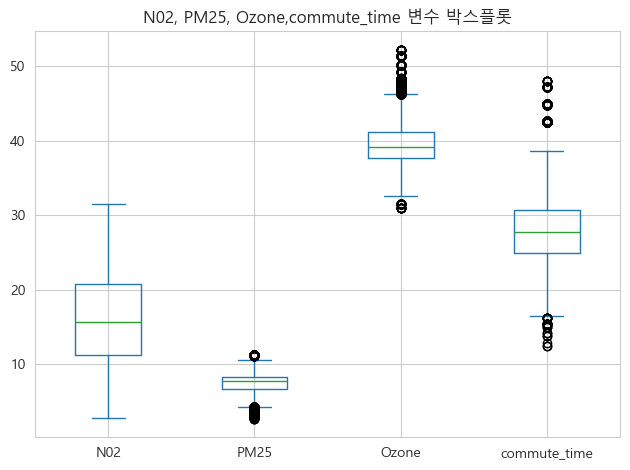

In [34]:
env_cols = ['N02', 'PM25', 'Ozone', 'commute_time']

# 각 환경 변수별 결측값 개수 출력
print("- 환경 변수별 결측값 개수:")
print(df[env_cols].isnull().sum())
print()

# 각 환경 변수의 분포를 박스플롯으로 시각화
plt.figure(figsize=(8, 5))
df_box = df[env_cols]
df_box.plot(kind='box')
plt.title("N02, PM25, Ozone,commute_time 변수 박스플롯")
plt.tight_layout()
plt.show()

  복합 지수 Welch t-test (target=0 vs 1)
  NO2XPM25XOzone             t= -0.851  p=0.3946  → 유의하지 않음
  NO2XPM25Xcommute_time      t=  2.268  p=0.0233  → 유의 (p<0.05)


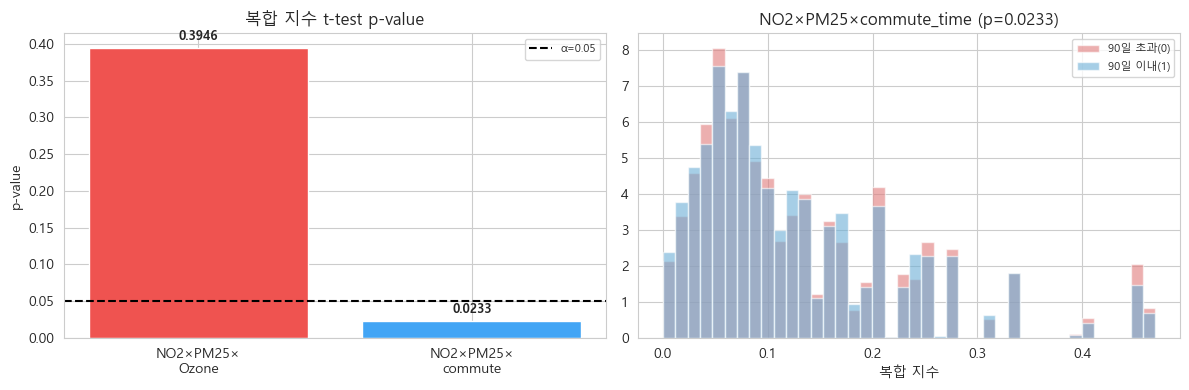


→ Ozone 포함 복합(NO2×PM25×Ozone)은 t-test 유의하지 않음
→ commute 포함 복합(NO2×PM25×commute_time)은 유의 → H3 근거


In [35]:
# 복합 지수 t-test만 검정 및 시각화

def welch_ttest(col):
    g0 = df.loc[df[target] == 0, col].dropna()
    g1 = df.loc[df[target] == 1, col].dropna()
    return stats.ttest_ind(g0, g1, equal_var=False)

# --- 복합 지수 생성 (MinMax 후 곱) ---
env_impute = df[['N02', 'PM25', 'Ozone', 'commute_time']].fillna(
    df[['N02', 'PM25', 'Ozone', 'commute_time']].mean())

sc_oz = MinMaxScaler().fit(env_impute[['N02', 'PM25', 'Ozone']])
scaled_oz = sc_oz.transform(env_impute[['N02', 'PM25', 'Ozone']])
df['NO2XPM25XOzone'] = scaled_oz[:, 0] * scaled_oz[:, 1] * scaled_oz[:, 2]

sc_cm = MinMaxScaler().fit(env_impute[['N02', 'PM25', 'commute_time']])
scaled_cm = sc_cm.transform(env_impute[['N02', 'PM25', 'commute_time']])
df['NO2XPM25Xcommute_time'] = scaled_cm[:, 0] * scaled_cm[:, 1] * scaled_cm[:, 2]

# --- 복합 지수 t-test (타겟 그룹 간) ---
print('=' * 55)
print('  복합 지수 Welch t-test (target=0 vs 1)')
print('=' * 55)
ttest_results = {}
for col in ['NO2XPM25XOzone', 'NO2XPM25Xcommute_time']:
    t, p = welch_ttest(col)
    ttest_results[col] = p
    flag = '유의 (p<0.05)' if p < 0.05 else '유의하지 않음'
    print(f'  {col:25s}  t={t:7.3f}  p={p:.4f}  → {flag}')

# --- 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tt_labels = ['NO2×PM25×\nOzone', 'NO2×PM25×\ncommute']
tt_ps = [ttest_results['NO2XPM25XOzone'], ttest_results['NO2XPM25Xcommute_time']]
colors_tt = ['#42A5F5' if p < 0.05 else '#EF5350' for p in tt_ps]
bars = axes[0].bar(tt_labels, tt_ps, color=colors_tt, edgecolor='white')
axes[0].axhline(0.05, color='black', lw=1.5, linestyle='--', label='α=0.05')
axes[0].set_title('복합 지수 t-test p-value')
axes[0].set_ylabel('p-value')
for bar, p in zip(bars, tt_ps):
    axes[0].text(bar.get_x() + bar.get_width() / 2, p + 0.01, f'{p:.4f}',
                 ha='center', fontsize=9, fontweight='bold')
axes[0].legend(fontsize=8)

g0_i = df.loc[df[target] == 0, 'NO2XPM25Xcommute_time']
g1_i = df.loc[df[target] == 1, 'NO2XPM25Xcommute_time']
axes[1].hist(g0_i, bins=40, alpha=0.6, label='90일 초과(0)', color='#e07b7b', density=True)
axes[1].hist(g1_i, bins=40, alpha=0.6, label='90일 이내(1)', color='#6baed6', density=True)
p_cm = ttest_results['NO2XPM25Xcommute_time']
axes[1].set_title(f'NO2×PM25×commute_time (p={p_cm:.4f})')
axes[1].set_xlabel('복합 지수')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\n→ Ozone 포함 복합(NO2×PM25×Ozone)은 t-test 유의하지 않음')
print('→ commute 포함 복합(NO2×PM25×commute_time)은 유의 → H3 근거')


## 가설 설정

EDA와 **수상작 주요 변수 분석** 셀 결과를 바탕으로, 모델링 전 검증 계획으로 정리한다. (Section 3: Feature Importance·정예+앙상블로 최종 확인)

| 가설 | 내용 | EDA·수상작 근거 (실측) | 검증 방향 |
|------|------|----------------------|----------|
| **H1. 인종(의료 형평성)** | `patient_race`는 90일 이내 진단(`DiagPeriodL90D=1`)과 연관될 수 있다. | 관측값만: Black·Asian **0.61–0.63**, White **0.66**; χ² **p≈0.049**. 결측 **49.5%**. | **Naive Bayes 보간** 후 단변량·앙상블 |
| **H2. 종양 위치(임상)** | Luo et al.(2023) 기준 7위치(`tumor_site`) 범주화 시 **위치별** 90일 이내 진단 비율이 다르다. | Overlapping **0.81**, Lower-inner **0.72**, Unspecified **0.57**; χ² **p≈4e-56**. | `breast_cancer_diagnosis_desc` → `tumor_site`·라벨 인코딩 |
| **H3. 환경(통근·오염 복합)** | **`NO2×PM25×commute_time`**이 타겟 그룹 간 분포 차이를 보인다. O₃ 포함 복합은 유의하지 않다. | Welch t-test: commute 복합 **p≈0.023** (유의); `NO2×PM25×Ozone` **p≈0.39** (비유의). 수상작·문헌상 O₃ 단독 효과는 약함. | **통근 포함 복합**을 핵심 피처로 설계; O₃ 단독 우월 가설은 기각 |
| **H4. 전이암 코드(신뢰성)** | 5자리 `metastatic_cancer_diagnosis_code` χ²는 유의하나 **Selvin 기준 미충족**. | 5자리: p≈2e-31, 기대빈도 <5 셀 **43%** → 4자리: **22%** (12/54셀, 기준 충족). | 전처리 **`meta_code4`** |
| **H5. ICD 체계** | ICD-10 vs ICD-9 혼재가 타겟 분포를 왜곡할 수 있다. | ICD-10 환자 90일 이내 비율 **≈78%**, ICD-9 **≈9.5%** (N: 9,915 vs 2,991). | 전처리 플래그 **`ICD_version`** |

## 전처리

In [37]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")

df = df_raw.copy()
tdf = pd.read_csv("data/test.csv")
ss  = pd.read_csv("data/sample_submission.csv")
target = "DiagPeriodL90D" 

#### (1) 환경 변수 결측(NO2, PM25, commute_time) 
 patient_zip2 기반의 평균 대체

In [38]:
df['patient_zip2']  = df['patient_zip3'].astype(str).str[:2]
tdf['patient_zip2'] = tdf['patient_zip3'].astype(str).str[:2]

for ds in [df, tdf]:
    for col in ['N02', 'PM25', 'commute_time']:
        ds[col] = ds.groupby('patient_zip2')[col].transform(lambda x: x.fillna(x.mean()))

In [39]:
# 각 컬럼의 결측치 개수 출력
for col in ['N02', 'PM25', 'commute_time']:
    missing_count = df[col].isnull().sum()
    print(f"{col} 결측치 개수: {missing_count}")

N02 결측치 개수: 0
PM25 결측치 개수: 0
commute_time 결측치 개수: 0


#### (2) N02×PM25×commute_time 복합 환경 지수
복합 환경변수 생성 및 MinMaxScaling

In [40]:
from sklearn.preprocessing import MinMaxScaler

# 스케일링 대상 컬럼
cols = ['N02', 'PM25', 'commute_time']

# MinMax 스케일러 정의
scaler = MinMaxScaler()

# df 정규화
df_scaled = pd.DataFrame(scaler.fit_transform(df[cols]), columns=cols, index=df.index)
df['N02xPM25xcommute_time'] = df_scaled['N02'] * df_scaled['PM25'] * df_scaled['commute_time']

# tdf 정규화 (df 기준으로 transform)
tdf_scaled = pd.DataFrame(scaler.transform(tdf[cols]), columns=cols, index=tdf.index)
tdf['N02xPM25xcommute_time'] = tdf_scaled['N02'] * tdf_scaled['PM25'] * tdf_scaled['commute_time']



#### (3) Train + Test 병합 (공통 전처리)

In [41]:
# define target variable and categorical features
cat_cols = list(tdf.columns[tdf.dtypes=="object"])
cols = [col for col in tdf.columns if col not in ["patient_id"]]
tdf[target] = np.nan

# concatenate train and test set
df = pd.concat([df,tdf[df.columns]],axis=0)

#### (4) clust + is_female: 기존 수상작 변수
- clust: `metastatic_cancer_diagnosis_code`의 자릿수 플래그 변수
- is_female: 성별데이터의 결함으로 `breast_cancer_diagnosis_desc`에서 성별 데이터 추출


In [42]:
df["clust"]=(df.metastatic_cancer_diagnosis_code.str.len()==4).astype("int")
df["is_female"] = df.breast_cancer_diagnosis_desc.str.contains("female").astype("int")
df["is_female"].value_counts()

is_female
1    18665
0       33
Name: count, dtype: int64

#### (5) meta_code4

In [43]:
# meta 칼럼에서 5자리 값을 4자리로 변환
df['meta_code4'] = df['metastatic_cancer_diagnosis_code'].astype(str).apply(lambda x: x[:4] if len(x) >= 5 else x)

# 결과 확인
print(df['meta_code4'].nunique())
print(df['meta_code4'].value_counts())

#metastatic_cancer_diagnosis_code 드랍하기
df = df.drop(columns=['metastatic_cancer_diagnosis_code'])

27
meta_code4
C773    10223
C795     2760
C798     1196
C779     1095
C780      910
C787      533
C799      399
C793      389
C792      239
C771      226
C770      192
C782      117
C778      116
C786       57
C781       40
C772       39
C794       29
C796       27
C788       25
C785       25
C797       17
C775       14
C790        8
C791        7
C784        6
C783        5
C774        4
Name: count, dtype: int64


#### (6) ICD_version

In [44]:
# ICD_version 파생변수 생성 (ICD-10이면 0, ICD-9이면 1)

df['ICD_version'] = np.where(df['breast_cancer_diagnosis_code'].astype(str).str.startswith('C'), 'ICD-10', 'ICD-9')
print(df['ICD_version'].value_counts())

ICD_version
ICD-10    14333
ICD-9      4365
Name: count, dtype: int64


#### (7) tumor_site — 논문 기반 종양 위치 변수

In [45]:
desc = df['breast_cancer_diagnosis_desc'].str.lower()
df['desc_lower'] = desc

# 세분화 버전 (race 결측 보완용)
df['tumor_site'] = np.select(
    [desc.str.contains('upper-inner'), desc.str.contains('lower-inner'),
     desc.str.contains('upper-outer'), desc.str.contains('lower-outer'),
     desc.str.contains('axillary tail'),
     desc.str.contains('central portion|nipple|areola'),
     desc.str.contains('overlapping|ovrlp'),
     desc.str.contains('unspecified|unsp')],
    ['Upper-inner','Lower-inner','Upper-outer','Lower-outer',
     'Axillary tail','Central','Overlapping','Unspecified'],
    default='Unspecified')

print(df['tumor_site'].value_counts())

tumor_site
Unspecified      10624
Upper-outer       3322
Overlapping       1380
Central           1071
Upper-inner       1003
Lower-outer        700
Lower-inner        489
Axillary tail      109
Name: count, dtype: int64


#### (8) patient_race 결측 — Naive Bayes 확률적 추론
 P(인종|유방암 종양 위치, 환자 거주지)=P(유방암 종양 위치|인종)xP(환자 거주지|인종)xP(인종)

1. P(tumor_site2 | race) 확률 데이터 프레임 생성

In [47]:
# 1. 논문 기반 6개 종양 위치 확률 (단위: %)
tumor_sites_main = ['Central', 'Upper-inner', 'Lower-inner', 'Upper-outer', 'Lower-outer', 'Axillary tail', 'Unspecified', 'Overlapping']
tumor_sites_all = tumor_sites_main

# 2. 인종 목록
races = ['White', 'Black', 'Asian', 'Hispanic', 'Other']

# 3. 논문 기반 확률 (6개 부위만)
paper_data = {
    'Central':      [8.5,   7.7,  10.3,  8.9,  16.79],
    'Upper-inner':  [16.6, 17.0,  19.7, 17.7,  13.87],
    'Lower-inner':  [8.3,   9.8,   8.3,  8.2,   6.57],
    'Upper-outer':  [54.9, 53.4,  50.6, 53.6,  51.46],
    'Lower-outer':  [10.7, 10.8,  10.4, 10.7,  10.58],
    'Axillary tail':[1.0,   1.3,   0.7,  0.8,   0.73],
    'Unspecified':  [55.72, 55.88, 64.62, 62.61, 49.93],
    'Overlapping':  [9.43,  10.53, 10.03,  7.48,  9.84]
}
# paper_data = {
#     'Central':      [8.5,   7.7,  9.68,  8.9,  16.79],
#     'Upper-inner':  [16.6, 17.0,  20.43, 17.7,  13.87],
#     'Lower-inner':  [8.3,   9.8,   9.68,  8.2,   6.57],
#     'Upper-outer':  [54.9, 53.4,  52.69, 53.6,  51.46],
#     'Lower-outer':  [10.7, 10.8,  5.38, 10.7,  10.58],
#     'Axillary tail':[1.0,   1.3,   2.15,  0.8,   0.73],
#     'Unspecified':  [55.72, 55.88, 64.62, 62.61, 49.93],
#     'Overlapping':  [9.43,  10.53, 10.03,  7.48,  9.84]
# }


# 4. 데이터프레임 생성
tumor_site_prob_per_race = pd.DataFrame(paper_data, index=races).T
tumor_site_prob_per_race.index.name = "Tumor Site"

# 5. 결과 출력
print("🎯 인종별 유방암 종양 위치 확률 테이블 (%):")
print(tumor_site_prob_per_race)


🎯 인종별 유방암 종양 위치 확률 테이블 (%):
               White  Black  Asian  Hispanic  Other
Tumor Site                                         
Central         8.50   7.70  10.30      8.90  16.79
Upper-inner    16.60  17.00  19.70     17.70  13.87
Lower-inner     8.30   9.80   8.30      8.20   6.57
Upper-outer    54.90  53.40  50.60     53.60  51.46
Lower-outer    10.70  10.80  10.40     10.70  10.58
Axillary tail   1.00   1.30   0.70      0.80   0.73
Unspecified    55.72  55.88  64.62     62.61  49.93
Overlapping     9.43  10.53  10.03      7.48   9.84


2. P(patient_zip3 | Race)

In [48]:
## P(zip3 | race) 데이터 프레임


# 1. 결측치가 없는 행만 필터링
df_valid = df[df['patient_race'].notna()].copy()

# 2. 인종과 patient_zip3에 따른 joint frequency table 생성
zip3_race_counts = (
    df_valid
    .groupby(['patient_race', 'patient_zip3'])
    .size()
    .unstack(fill_value=0)
)

# 3. 인종별로 zip3 값의 확률 계산 (행 기준 정규화)
zip3_given_race_prob = zip3_race_counts.div(zip3_race_counts.sum(axis=1), axis=0)

# 4. 결과 확인
print("🎯 P(zip3 | race) 조건부 확률 테이블:")
zip3_given_race_prob

🎯 P(zip3 | race) 조건부 확률 테이블:


patient_zip3,101,103,104,105,106,107,108,109,110,111,...,982,983,984,985,986,988,989,990,991,992
patient_race,,,,,,,,,,,,,,,,,,,,,
Asian,0.000000,0.003846,0.011538,0.000000,0.000000,0.000000,0.001923,0.000000,0.000000,0.000000,...,0.001923,0.001923,0.007692,0.000000,0.003846,0.000000,0.000000,0.000000,0.00000,0.000000
Black,0.000000,0.001277,0.014049,0.001277,0.000000,0.001277,0.000000,0.000000,0.000000,0.001277,...,0.000000,0.000000,0.000639,0.000000,0.000639,0.000000,0.000000,0.000000,0.00000,0.000639
Hispanic,0.000000,0.000000,0.010204,0.001701,0.000000,0.001701,0.000850,0.001701,0.000000,0.000850,...,0.000000,0.000850,0.000000,0.000000,0.000850,0.003401,0.001701,0.000000,0.00000,0.000000
Other,0.000000,0.001046,0.005230,0.002092,0.000000,0.000000,0.000000,0.002092,0.001046,0.001046,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001046,0.000000,0.00000,0.000000
White,0.000193,0.001733,0.002888,0.001925,0.000193,0.000193,0.000385,0.000770,0.000578,0.000963,...,0.003658,0.001733,0.001155,0.000963,0.002118,0.001540,0.000578,0.000578,0.00077,0.001540


3. P(Race)

In [49]:
race_prob = df['patient_race'].value_counts(normalize=True).reindex(races, fill_value=0)

race_prob

patient_race
White       0.551849
Black       0.166383
Asian       0.055249
Hispanic    0.124947
Other       0.101572
Name: proportion, dtype: float64

4. patient_race 결측치 채우기

In [50]:
## df (zip3, 확률 0.7 이상일 때만 대체)


# 대상 인종 및 종양 위치
races = ['White', 'Black', 'Asian', 'Hispanic', 'Other']
tumor_sites_all = ['Central', 'Upper-inner', 'Lower-inner', 'Upper-outer', 'Lower-outer',
                   'Axillary tail', 'Unspecified', 'Overlapping']

# 1. 결측치 행 추출
missing = df[df['patient_race'].isna()].copy()
total_missing = len(missing)

# 2. 추론
filled_count = 0
predicted_labels = {}
threshold = 0.7

for idx, row in missing.iterrows():
    tumor = row['tumor_site']
    zip3 = row['patient_zip3']

    probs = {}
    for race in races:
        p_tumor = tumor_site_prob_per_race.at[tumor, race] / 100 if tumor in tumor_site_prob_per_race.index else 0
        p_zip = zip3_given_race_prob.at[race, zip3] if zip3 in zip3_given_race_prob.columns else 0
        p_race = race_prob[race]
        probs[race] = p_tumor * p_zip * p_race

    total_prob = sum(probs.values())
    if total_prob == 0:
        continue

    # 합이 1이 되도록 정규화 과정 꼭 해줘야 됨. 지금 이 코드는 분모가 없는 단순 비례 관계일 뿐이고, 이후 0.8 이상이라는 확률 조건을 사용해야 하므로
    normalized_probs = {k: v / total_prob for k, v in probs.items()}
    best_race = max(normalized_probs, key=normalized_probs.get)
    max_prob = normalized_probs[best_race]

    if max_prob >= threshold:
        predicted_labels[idx] = best_race
        filled_count += 1

# 3. 실제 채우기
df.loc[predicted_labels.keys(), 'patient_race'] = pd.Series(predicted_labels)

# 4. 출력
print("✅ Naive Bayes 기반 인종 결측치 채우기 완료")
print(f"🔹 전체 결측치 수: {total_missing}")
print(f"🔹 채워진 결측치 수 (확률 ≥ {threshold}): {filled_count}")
print(f"🔹 채워진 비율: {round(filled_count / total_missing * 100, 2)}%")
print(f"🔸 남은 결측치 수: {df['patient_race'].isna().sum()}")


✅ Naive Bayes 기반 인종 결측치 채우기 완료
🔹 전체 결측치 수: 9286
🔹 채워진 결측치 수 (확률 ≥ 0.7): 3774
🔹 채워진 비율: 40.64%
🔸 남은 결측치 수: 4828


#### (9) Columns Drop
ZIP3 수준 중복 컬럼 제거

In [51]:
# Drop some features

# List of columns to iterate over
columns_to_iterate = [col for col in df.columns if col not in ["patient_zip3", "N02xPM25xcommute_time"]]

# Iterate over each column
for col in columns_to_iterate:
    # Your code to operate on each column goes here
    df["check"]=df.groupby(["patient_zip3","N02xPM25xcommute_time"])[col].transform("nunique")
    if df["check"].max()==1:
        print("dropped ",col)
        df=df.drop(col,axis=1)
        # tdf=tdf.drop(col,axis=1)
df=df.drop("check",axis=1)

dropped  patient_gender
dropped  metastatic_first_novel_treatment
dropped  metastatic_first_novel_treatment_type
dropped  population
dropped  density
dropped  age_median
dropped  age_under_10
dropped  age_10_to_19
dropped  age_20s
dropped  age_30s
dropped  age_40s
dropped  age_50s
dropped  age_60s
dropped  age_70s
dropped  age_over_80
dropped  male
dropped  female
dropped  married
dropped  divorced
dropped  never_married
dropped  widowed
dropped  family_size
dropped  family_dual_income
dropped  income_household_median
dropped  income_household_under_5
dropped  income_household_5_to_10
dropped  income_household_10_to_15
dropped  income_household_15_to_20
dropped  income_household_20_to_25
dropped  income_household_25_to_35
dropped  income_household_35_to_50
dropped  income_household_50_to_75
dropped  income_household_75_to_100
dropped  income_household_100_to_150
dropped  income_household_150_over
dropped  income_household_six_figure
dropped  income_individual_median
dropped  home_owner

In [52]:
df = df.drop(columns=[
    'Region', 'patient_zip3',
    'desc_lower',
    # 'breast_cancer_diagnosis_code_mapped',
    # 'breast_cancer_diagnosis_desc_mapped',
    # 'breast_cancer_diagnosis_desc',
    'breast_cancer_diagnosis_code',
])

In [55]:
print(df.columns.to_list())
print(len(df.columns))

['patient_id', 'patient_race', 'payer_type', 'patient_state', 'patient_age', 'bmi', 'breast_cancer_diagnosis_desc', 'Division', 'DiagPeriodL90D', 'N02xPM25xcommute_time', 'clust', 'is_female', 'meta_code4', 'ICD_version', 'tumor_site']
15


#### (8) 인코딩

In [57]:
categorical_cols = [
    col for col in df.columns
    if df[col].dtype == 'str' and col != 'tumor_site'
]
categorical_cols

['patient_race',
 'payer_type',
 'patient_state',
 'breast_cancer_diagnosis_desc',
 'Division',
 'meta_code4',
 'ICD_version']

In [58]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype="int")

tumor_site는 라벨 인코딩

In [ ]:
df['tumor_site'] = df['tumor_site'].str.strip()

# 사용자 정의 순서에 따라 숫자 부여
tumor_site_order = {
    'Central': 7,
    'Overlapping': 6,
    'Axillary tail': 5,
    'Upper-inner': 1,
    'Lower-inner': 2,
    'Upper-outer': 3,
    'Lower-outer': 4,
    'Unspecified': 0
}

# 결측치는 가장 낮은 영향도와 비슷하게 처리 (예: Unspecified 취급)
df['tumor_site'] = df['tumor_site'].fillna('Unspecified')

# 사용자 정의 라벨 인코딩 적용
df['tumor_site_encoded'] = df['tumor_site'].map(tumor_site_order)

# 결과 확인
print(df[['tumor_site', 'tumor_site_encoded']].head(100))


     tumor_site  tumor_site_encoded
0   Unspecified                   0
1   Upper-outer                   3
2       Central                   7
3   Upper-inner                   1
4   Unspecified                   0
..          ...                 ...
95  Upper-outer                   3
96  Unspecified                   0
97  Unspecified                   0
98  Upper-inner                   1
99  Lower-outer                   4

[100 rows x 2 columns]


In [61]:
df = df.drop(columns=['tumor_site'])

# do label encoding for categorical columns
le = LabelEncoder()
for col in cat_cols:
    try:
        df[col]=le.fit_transform(df[col]).astype("int")
        print(col)
    except:
        continue

타겟 분리

In [ ]:
tdf = df[df[target].isna()]
df_ = df[df[target].notna()]
len(df), len(tdf)
# 분리하는 코드

(12906, 5792)

In [65]:
tdf_final = tdf.copy()
df_final = df.copy()

## 모델링

- (기존) base model: 동일 구조 CatBoost 2개 + XGBoost → 앙상블 다양성 부족
- (개선) base model: catboost + xgboost + random forest

| 모델 | 역할 |
|------|------|
| CatBoost | 범주형 직접 처리, 결측 내성 |
| RandomForest | 배깅 기반 분산 축소 |
| XGBoost | 잔차 학습, 그래디언트 부스팅 |
| Logistic Regression (meta) | OOF 예측 결합 → 최종 확률 출력 |

In [66]:
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

model_cb  = CatBoostClassifier(iterations=500, silent=True, learning_rate=0.05,
                                depth=10, eval_metric='AUC', random_seed=42)
model_rf  = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model_xgb = XGBClassifier(learning_rate=0.1, max_depth=6, n_estimators=100, subsample=0.9)
meta      = LogisticRegression()

In [67]:
drop_cols = ['patient_id', target, 'patient_zip3', 'patient_state']
cols = [c for c in df_final.columns if c not in drop_cols]
meta_feats = ['pred1','pred2','pred3']
print(f"학습 피처 수: {len(cols)}")

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
preds_all = pd.DataFrame()

for fold, (tr_idx, val_idx) in enumerate(kf.split(df_final, df_final[target])):
    trn, val = df_final.iloc[tr_idx], df_final.iloc[val_idx].copy()

    val['pred1'] = model_cb.fit(trn[cols], trn[target]).predict_proba(val[cols])[:,1]
    val['pred2'] = model_rf.fit(trn[cols], trn[target]).predict_proba(val[cols])[:,1]
    val['pred3'] = model_xgb.fit(trn[cols], trn[target]).predict_proba(val[cols])[:,1]

    tdf_f = tdf_final.copy()
    tdf_f['pred1'] = model_cb.predict_proba(tdf_final[cols])[:,1]
    tdf_f['pred2'] = model_rf.predict_proba(tdf_final[cols])[:,1]
    tdf_f['pred3'] = model_xgb.predict_proba(tdf_final[cols])[:,1]
    tdf_f['pred']  = meta.fit(val[meta_feats], val[target]).predict_proba(tdf_f[meta_feats])[:,1]

    preds_all = pd.concat([preds_all, tdf_f], axis=0)
    print(f"Fold {fold+1:2d} 완료")

print("✅ 학습 완료")

학습 피처 수: 148
Fold  1 완료
Fold  2 완료
Fold  3 완료
Fold  4 완료
Fold  5 완료
Fold  6 완료
Fold  7 완료
Fold  8 완료
Fold  9 완료
Fold 10 완료
✅ 학습 완료


#### Feature Importance — 가설 검증

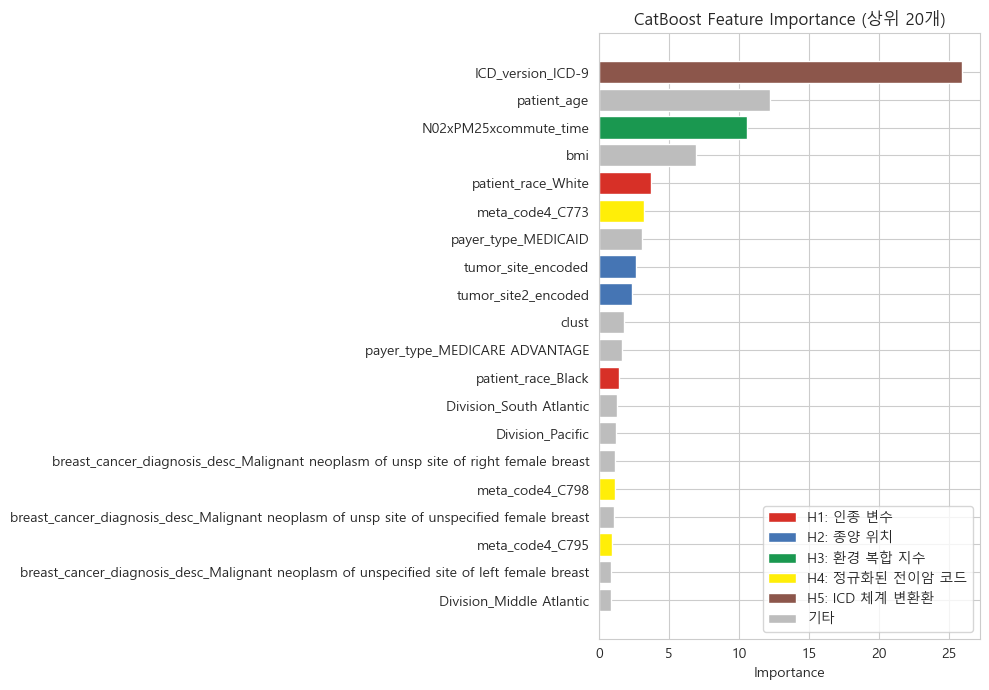

In [ ]:
from matplotlib.patches import Patch

feat_imp = (pd.DataFrame({'Feature': cols, 'Importance': model_cb.feature_importances_})
            .sort_values('Importance', ascending=False).head(20))

color_map = []
for f in feat_imp['Feature']:
    if 'race'       in f: color_map.append('#d73027')   # H1: 인종
    elif 'tumor'    in f: color_map.append('#4575b4')   # H2: 종양 위치
    elif 'N02xPM25' in f: color_map.append('#1a9850')   # H3: 환경
    elif 'meta_code4' in f: color_map.append('#ffee08') # H4: meta_code4 
    elif 'ICD_version' in f: color_map.append('#ff7f0e') # H5: Icd_version 
    else:                  color_map.append('#bdbdbd')

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1], color=color_map[::-1])
ax.set_title('CatBoost Feature Importance (상위 20개)')
ax.set_xlabel('Importance')

legend_els = [Patch(facecolor='#d73027', label='H1: 인종 변수'),
              Patch(facecolor='#4575b4', label='H2: 종양 위치'),
              Patch(facecolor='#1a9850', label='H3: 환경 복합 지수'),
              Patch(facecolor='#ffee08', label='H4: 정규화된 전이암 코드'),
              Patch(facecolor='#ff7f0e', label='H5: ICD 체계 변환환'),
              Patch(facecolor='#bdbdbd', label='기타')]
ax.legend(handles=legend_els, loc='lower right')
plt.tight_layout()
plt.savefig('feature_importance_portfolio.png', dpi=150, bbox_inches='tight')
plt.show()